## 8d. R_TR vs Dispatch Cost + Exposure Count

Pareto frontier: does paying more dispatch cost buy better resilience?
Second panel shows high-exposure arc count vs cost.

In [ ]:
def plot_cost_saving_by_weight(df):
    """Cost saving (S1 - S2 dispatch) by weight, one line per S2 config."""
    sub = df.dropna(subset=["cost_saving", "s1_dispatch_cost"]).copy()
    if sub.empty:
        print("No cost saving data available")
        return
    # Filter out zero s1_dispatch_cost to avoid division issues
    sub = sub[sub["s1_dispatch_cost"] > 0]

    sub["saving_pct"] = sub["cost_saving"] / sub["s1_dispatch_cost"] * 100

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    config_colors = {"baseline": "#bdbdbd", "mixed": "#74c0fc",
                     "even": "#ffa94d", "full": "#69db7c"}

    for cfg in config_order:
        cfg_df = sub[sub["s2_config"] == cfg]
        if cfg_df.empty:
            continue

        agg = cfg_df.groupby("weight").agg(
            avg_saving=("cost_saving", "mean"),
            avg_pct=("saving_pct", "mean"),
        ).reset_index().sort_values("weight")

        ax1.plot(agg["weight"], agg["avg_saving"], marker="o", markersize=5,
                 label=cfg, color=config_colors.get(cfg, "gray"), linewidth=1.5)
        ax2.plot(agg["weight"], agg["avg_pct"], marker="o", markersize=5,
                 label=cfg, color=config_colors.get(cfg, "gray"), linewidth=1.5)

    ax1.set_xlabel("Stage 1 Diversification Weight")
    ax1.set_ylabel("Absolute Cost Saving")
    ax1.set_title("S2 Dispatch Cost Saving (Absolute)")
    ax1.axhline(0, color="k", linewidth=0.8, linestyle="--")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.set_xlabel("Stage 1 Diversification Weight")
    ax2.set_ylabel("Cost Saving (%)")
    ax2.set_title("S2 Dispatch Cost Saving (Percentage)")
    ax2.axhline(0, color="k", linewidth=0.8, linestyle="--")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    fig.suptitle("Stage 2 Packing Efficiency", fontsize=13, y=1.02)
    fig.tight_layout()
    plt.show()


plot_cost_saving_by_weight(df)

## 8c. Dispatch Cost Saving by Weight

S2 packing can reduce dispatch cost below S1 allocation (fewer trips needed).
Shows absolute and percentage cost saving as diversification weight increases.

In [ ]:
def plot_r1_vs_rtr(df):
    """R_1 vs R_TR scatter, colored by S2 config."""
    sub = df.dropna(subset=["r_1", "r_tr"])
    if sub.empty:
        print("No R_1/R_TR data available")
        return

    fig, ax = plt.subplots(figsize=(7, 6))

    config_colors = {"baseline": "#bdbdbd", "mixed": "#74c0fc",
                     "even": "#ffa94d", "full": "#69db7c"}

    for cfg in config_order:
        cfg_df = sub[sub["s2_config"] == cfg]
        if cfg_df.empty:
            continue
        ax.scatter(
            cfg_df["r_tr"], cfg_df["r_1"],
            c=config_colors.get(cfg, "gray"), alpha=0.6, s=50,
            label=cfg, edgecolors="black", linewidths=0.3
        )

    # Reference line: R_1 = R_TR
    lims = [min(sub["r_tr"].min(), sub["r_1"].min()) - 0.05,
            max(sub["r_tr"].max(), sub["r_1"].max()) + 0.05]
    ax.plot(lims, lims, "k--", alpha=0.3, linewidth=1, label="$R_1 = R_{TR}$")

    ax.set_xlabel("$R_{TR}$ (Arc-level resilience)")
    ax.set_ylabel("$R_1$ (Trip-level resilience)")
    ax.set_title("$R_1$ vs $R_{TR}$ by Stage 2 Configuration")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()


plot_r1_vs_rtr(df)

In [ ]:
def plot_rtr_vs_weight(df):
    """R_TR vs diversification weight, one line per instance."""
    # R_TR only depends on S1 — use baseline to avoid duplicates
    sub = df[(df["s2_config"] == "baseline") & df["r_tr"].notna()].copy()
    if sub.empty:
        print("No R_TR data available")
        return

    fig, ax = plt.subplots(figsize=(10, 5))

    size_markers = {"paper": "o", "small": "s", "medium": "^", "large": "D",
                    "xlarge": "P", "industrylite": "X"}
    size_colors = {"paper": "#2ca02c", "small": "#1f77b4", "medium": "#ff7f0e",
                   "large": "#d62728", "xlarge": "#9467bd", "industrylite": "#8c564b"}

    for inst in sorted(sub["instance_name"].unique()):
        inst_df = sub[sub["instance_name"] == inst].sort_values("weight")
        size = inst_df["instance_size"].iloc[0]
        ax.plot(
            inst_df["weight"], inst_df["r_tr"],
            marker=size_markers.get(size, "o"),
            color=size_colors.get(size, "gray"),
            alpha=0.7, linewidth=1.2, markersize=6, label=inst
        )

    ax.set_xlabel("Stage 1 Diversification Weight")
    ax.set_ylabel("$R_{TR}$")
    ax.set_title("Transport Resilience vs Diversification Weight")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1.05)
    fig.tight_layout()
    plt.show()


plot_rtr_vs_weight(df)

In [ ]:
def plot_cross_comparison(df_twostage, df_bench):
    """Compare one-shot vs two-stage: time, cost, grounding."""
    if df_bench is None:
        print("No benchmark data loaded — skipping cross-comparison")
        return

    # --- Prepare two-stage summary (one row per instance × weight, baseline config) ---
    ts = df_twostage[df_twostage["s2_config"] == "baseline"].copy()
    ts["total_time"] = ts["s1_time"] + ts["s2_time"]
    ts_agg = ts.groupby(["instance_name", "instance_size"]).agg(
        ts_total_time=("total_time", "mean"),
        ts_s1_time=("s1_time", "mean"),
        ts_s2_time=("s2_time", "mean"),
        ts_cost=("nominal_cost", "mean"),
    ).reset_index()

    # --- Prepare benchmark summary (best cost per instance × solver) ---
    # Use num_bins with best cost for each solver
    bench_best = df_bench.loc[
        df_bench.groupby(["solver", "instance"])["cost"].idxmin()
    ].copy()
    bench_best = bench_best.rename(columns={
        "instance": "instance_name",
        "avg_total_time": "os_total_time",
        "cost": "os_cost",
        "atoms": "os_atoms",
    })

    # --- Merge on instance name ---
    common_instances = set(ts_agg["instance_name"]) & set(bench_best["instance_name"])
    if not common_instances:
        print("No common instances between two-stage and benchmark")
        print(f"  Two-stage instances: {ts_agg['instance_name'].unique()[:5]}")
        print(f"  Benchmark instances: {bench_best['instance_name'].unique()[:5]}")
        return

    merged = ts_agg[ts_agg["instance_name"].isin(common_instances)].merge(
        bench_best[["instance_name", "solver", "os_total_time", "os_cost", "os_atoms"]],
        on="instance_name", how="inner"
    )

    if merged.empty:
        print("No overlapping data after merge")
        return

    print(f"Cross-comparison on {len(common_instances)} instances:")
    print(f"  {sorted(common_instances)}")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # --- Panel 1: Solve Time ---
    ax = axes[0]
    for solver in merged["solver"].unique():
        s_df = merged[merged["solver"] == solver]
        ax.scatter(s_df["os_total_time"], s_df["ts_total_time"],
                   label=f"vs {solver}", s=80, alpha=0.7, edgecolors="k", linewidths=0.5)
    max_time = max(merged["os_total_time"].max(), merged["ts_total_time"].max()) * 1.1
    ax.plot([0, max_time], [0, max_time], "k--", alpha=0.4, label="x=y")
    ax.set_xlabel("One-shot total time (s)")
    ax.set_ylabel("Two-stage (S1+S2) time (s)")
    ax.set_title("Solve Time Comparison")
    ax.legend(fontsize=8)

    # --- Panel 2: Solution Cost ---
    ax = axes[1]
    for solver in merged["solver"].unique():
        s_df = merged[merged["solver"] == solver]
        ax.scatter(s_df["os_cost"], s_df["ts_cost"],
                   label=f"vs {solver}", s=80, alpha=0.7, edgecolors="k", linewidths=0.5)
    max_cost = max(merged["os_cost"].max(), merged["ts_cost"].max()) * 1.1
    ax.plot([0, max_cost], [0, max_cost], "k--", alpha=0.4, label="x=y")
    ax.set_xlabel("One-shot cost (best)")
    ax.set_ylabel("Two-stage S1 cost")
    ax.set_title("Solution Quality Comparison")
    ax.legend(fontsize=8)

    # --- Panel 3: Time breakdown bar ---
    ax = axes[2]
    # Average times by approach
    ts_times = ts_agg[ts_agg["instance_name"].isin(common_instances)]
    avg_s1 = ts_times["ts_s1_time"].mean()
    avg_s2 = ts_times["ts_s2_time"].mean()

    bar_data = {"Two-Stage\n(S1+S2)": [avg_s1, avg_s2]}
    for solver in merged["solver"].unique():
        s_df = merged[merged["solver"] == solver]
        bar_data[f"One-Shot\n({solver})"] = [s_df["os_total_time"].mean(), 0]

    x_labels = list(bar_data.keys())
    s1_vals = [v[0] for v in bar_data.values()]
    s2_vals = [v[1] for v in bar_data.values()]

    x = np.arange(len(x_labels))
    ax.bar(x, s1_vals, label="S1 / One-shot", color="steelblue")
    ax.bar(x, s2_vals, bottom=s1_vals, label="S2", color="coral")
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    ax.set_ylabel("Avg Time (s)")
    ax.set_title("Average Solve Time Breakdown")
    ax.legend()

    fig.suptitle("One-Shot vs Two-Stage Decomposition", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

    # --- Summary table ---
    print("\n--- Cross-comparison summary ---")
    for solver in merged["solver"].unique():
        s_df = merged[merged["solver"] == solver]
        print(f"\n  vs {solver} ({len(s_df)} instances):")
        print(f"    Avg one-shot time:  {s_df['os_total_time'].mean():.2f}s")
        print(f"    Avg two-stage time: {s_df['ts_total_time'].mean():.2f}s")
        speedup = s_df["os_total_time"].mean() / max(s_df["ts_total_time"].mean(), 0.001)
        print(f"    Speedup factor:     {speedup:.1f}x")
        print(f"    Avg one-shot cost:  {s_df['os_cost'].mean():.0f}")
        print(f"    Avg two-stage cost: {s_df['ts_cost'].mean():.0f}")


plot_cross_comparison(df, bench)

In [ ]:
# Load benchmark one-shot results
BENCHMARK_CSV = "../benchmark/results/benchmark_summaryTest.csv"

try:
    bench = pd.read_csv(BENCHMARK_CSV)
    print(f"Loaded benchmark: {len(bench)} rows")
    print(f"Solvers: {bench['solver'].unique()}")
    print(f"Sizes: {bench['instance_size'].unique()}")
except FileNotFoundError:
    bench = None
    print(f"Benchmark CSV not found at {BENCHMARK_CSV}")
    print("Update BENCHMARK_CSV path to enable cross-comparison")

# Two-Stage Resilience Experiment Analysis

Visualisations for the two-stage clingcon encoding results.

**Plots:**
1. R_α degradation curves (single & global)
2. S1 cost trajectory (anytime convergence)
3. S2 cost trajectory (soft constraint optimisation)
4. Ablation bar chart (mono + concentrated counts)
5. R_α single vs global heatmap
6. R_1 by config × instance size
7. Scalability (S1 + S2 time by size)
8. Cost-resilience Pareto (dispatch cost vs R_1)
9. Relative cost increase: S2 configs vs baseline across weights

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 6)

In [3]:
# Load data — adjust path to your results CSV
CSV_PATH = "results/test.csv"

df = pd.read_csv(CSV_PATH)
df = df[df["status"] == "OK"].copy()

# Coerce numeric columns
numeric_cols = [
    "r_tr", "r_1", "k_1", "nominal_cost", "s1_dispatch_cost",
    "s2_dispatch_cost", "cost_saving", "mono_count",
    "concentrated_count", "weight", "s1_time", "s2_time",
]
alpha_vals = [0.2, 0.4, 0.6, 0.8]
for strat in ["heaviest", "first", "last"]:
    for mode in ["single", "global"]:
        for a in alpha_vals:
            col = f"r_{strat}_{mode}_{a}"
            if col in df.columns:
                numeric_cols.append(col)

for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Size ordering for plots
size_order = ["paper", "small", "medium", "large", "xlarge", "industrylite"]
config_order = ["baseline", "mixed", "even", "full"]

df["s2_config"] = pd.Categorical(df["s2_config"], categories=config_order, ordered=True)
if "instance_size" in df.columns:
    df["instance_size"] = pd.Categorical(
        df["instance_size"], categories=size_order, ordered=True
    )

print(f"Loaded {len(df)} rows")
print(f"Instances: {df['instance_name'].unique()}")
print(f"Weights: {sorted(df['weight'].unique())}")
print(f"Configs: {df['s2_config'].unique().tolist()}")
df.head()

Loaded 8 rows
Instances: <StringArray>
['layered_paper']
Length: 1, dtype: str
Weights: [np.int64(0), np.int64(10000)]
Configs: ['baseline', 'mixed', 'even', 'full']


,instance_name,instance_type,instance_size,seed,n_locations,n_parts,n_routes,n_transports,density,capacity_tightness,...,first_s2_dispatch_cost,first_r_heaviest_single_0.2,first_r_heaviest_single_0.4,first_r_heaviest_single_0.6,first_r_heaviest_single_0.8,first_r_heaviest_global_0.2,first_r_heaviest_global_0.4,first_r_heaviest_global_0.6,first_r_heaviest_global_0.8,status
0,layered_paper,layered,paper,0,5,2,11,2,0.275,0.982,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OK
1,layered_paper,layered,paper,0,5,2,11,2,0.275,0.982,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OK
2,layered_paper,layered,paper,0,5,2,11,2,0.275,0.982,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OK
3,layered_paper,layered,paper,0,5,2,11,2,0.275,0.982,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OK
4,layered_paper,layered,paper,0,5,2,11,2,0.275,0.982,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OK


## 1. R_α Degradation Curves

How resilience drops as the survival fraction α decreases. 
One line per S2 config. Separate panels for single-arc vs global disruption.

## 1b. R_TR vs Diversification Weight

Per-instance lines showing how increasing weight improves arc-level resilience.
Uses baseline config only (R_TR only depends on Stage 1).

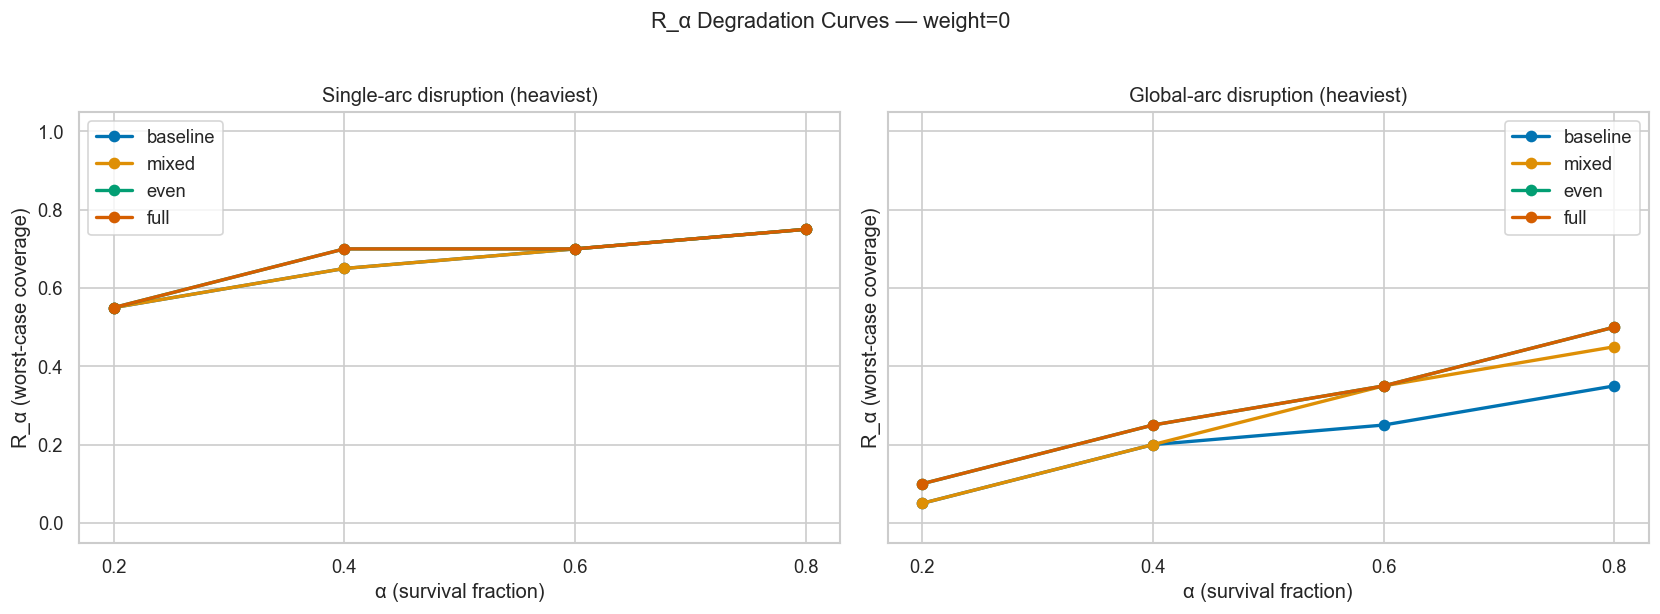

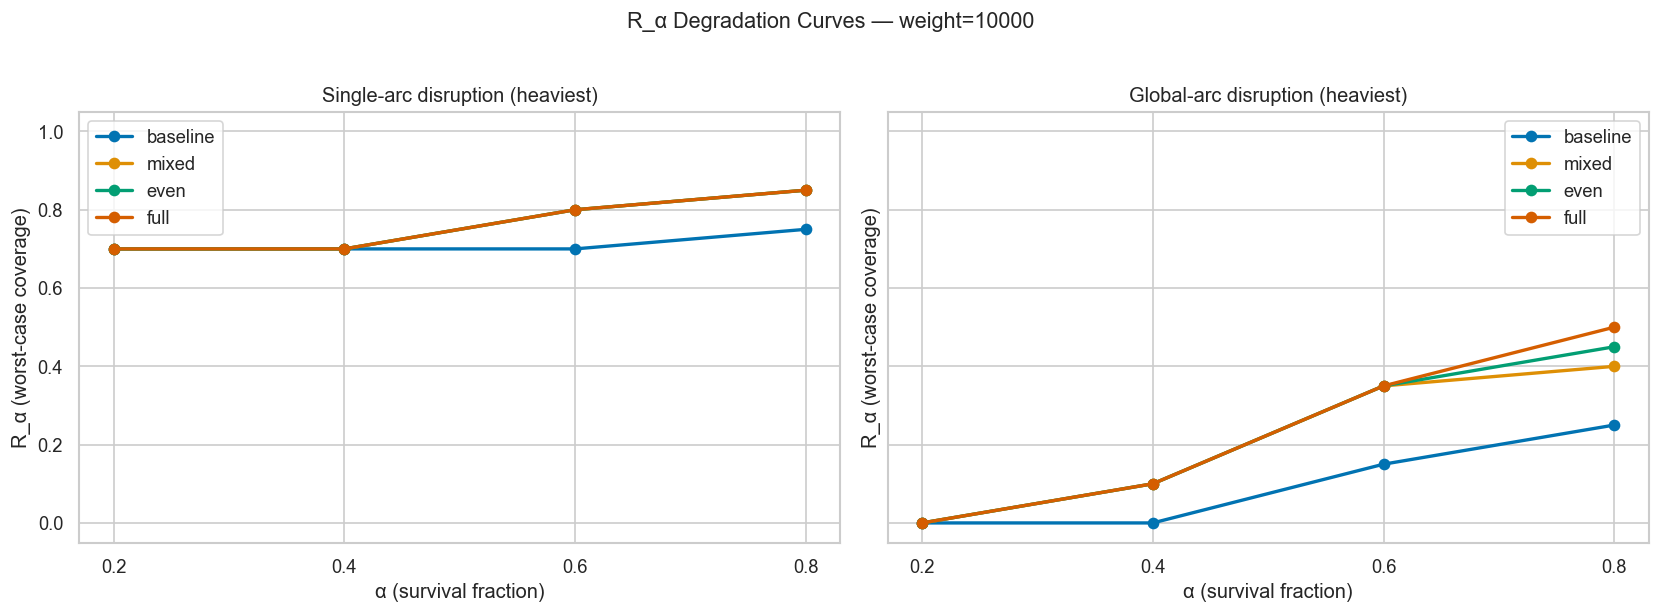

In [15]:
def plot_r_alpha_degradation(df, strategy="heaviest", weight=None):
    """R_alpha curves: one line per config, panels for single vs global."""
    sub = df.copy()
    if weight is not None:
        sub = sub[sub["weight"] == weight]

    modes = ["single", "global"]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    for ax, mode in zip(axes, modes):
        for config in config_order:
            cfg_df = sub[sub["s2_config"] == config]
            if cfg_df.empty:
                continue
            means = []
            for a in alpha_vals:
                col = f"r_{strategy}_{mode}_{a}"
                if col in cfg_df.columns:
                    means.append(cfg_df[col].mean())
                else:
                    means.append(np.nan)
            ax.plot(alpha_vals, means, marker="o", label=config, linewidth=2)

        ax.set_xlabel("α (survival fraction)")
        ax.set_ylabel("R_α (worst-case coverage)")
        ax.set_title(f"{mode.title()}-arc disruption ({strategy})")
        ax.legend()
        ax.set_ylim(-0.05, 1.05)
        ax.set_xticks(alpha_vals)

    w_str = f"weight={weight}" if weight is not None else "all weights"
    fig.suptitle(f"R_α Degradation Curves — {w_str}", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


# Plot for each weight present
for w in sorted(df["weight"].unique()):
    plot_r_alpha_degradation(df, strategy="heaviest", weight=w)

## 2. S1 Cost Trajectory (Anytime Convergence)

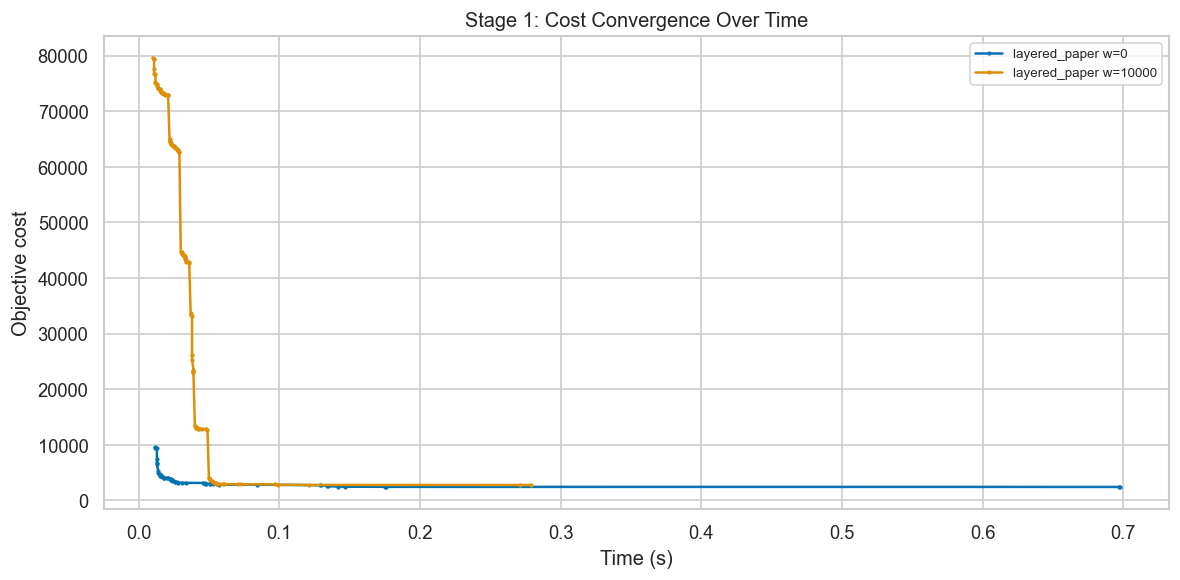

In [26]:
def plot_s1_trajectory(df):
    """Plot S1 cost over time for each unique (instance, weight) pair."""
    # Get unique S1 runs (one per instance × weight)
    seen = set()
    trajectories = []
    for _, row in df.iterrows():
        key = (row["instance_name"], row["weight"])
        if key in seen:
            continue
        seen.add(key)
        try:
            traj = json.loads(row["s1_trajectory"])
            trajectories.append((key, traj))
        except (json.JSONDecodeError, TypeError):
            continue

    if not trajectories:
        print("No S1 trajectories found")
        return

    fig, ax = plt.subplots(figsize=(10, 5))
    for (inst, w), traj in trajectories:
        times = [p["time"] for p in traj]
        costs = [p["cost"] for p in traj]
        ax.plot(times, costs, marker=".", markersize=3, label=f"{inst} w={w}")

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Objective cost")
    ax.set_title("Stage 1: Cost Convergence Over Time")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


plot_s1_trajectory(df)

## 3. S2 Cost Trajectory (Soft Constraint Optimisation)

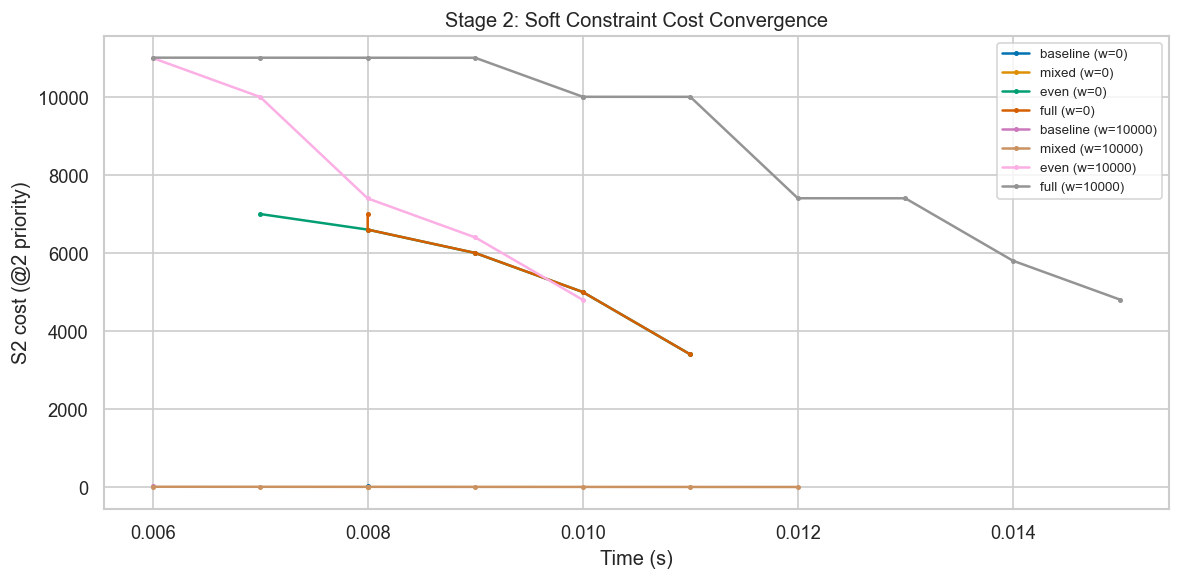

In [27]:
def plot_s2_trajectory(df):
    """Plot S2 multi-level cost trajectory per config."""
    fig, ax = plt.subplots(figsize=(10, 5))

    for _, row in df.iterrows():
        try:
            traj = json.loads(row["s2_trajectory"])
        except (json.JSONDecodeError, TypeError):
            continue
        if not traj:
            continue

        config = row["s2_config"]
        times = [p["time"] for p in traj]
        # Use first cost level (@2 priority — soft constraint penalty)
        costs = [
            p["cost"][0] if isinstance(p["cost"], list) else p["cost"]
            for p in traj
        ]
        ax.plot(times, costs, marker=".", markersize=4,
                label=f"{config} (w={int(row['weight'])})")

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("S2 cost (@2 priority)")
    ax.set_title("Stage 2: Soft Constraint Cost Convergence")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


plot_s2_trajectory(df)

## 4. Ablation Bar Chart (Mono + Concentrated Counts)

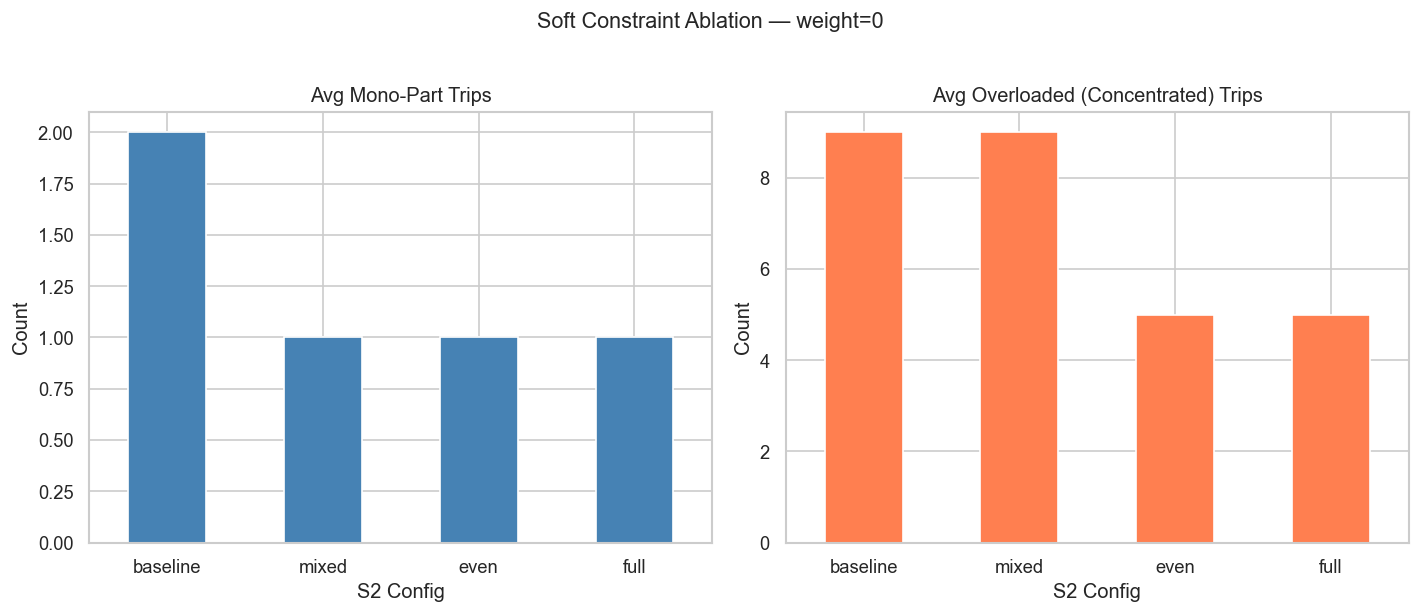

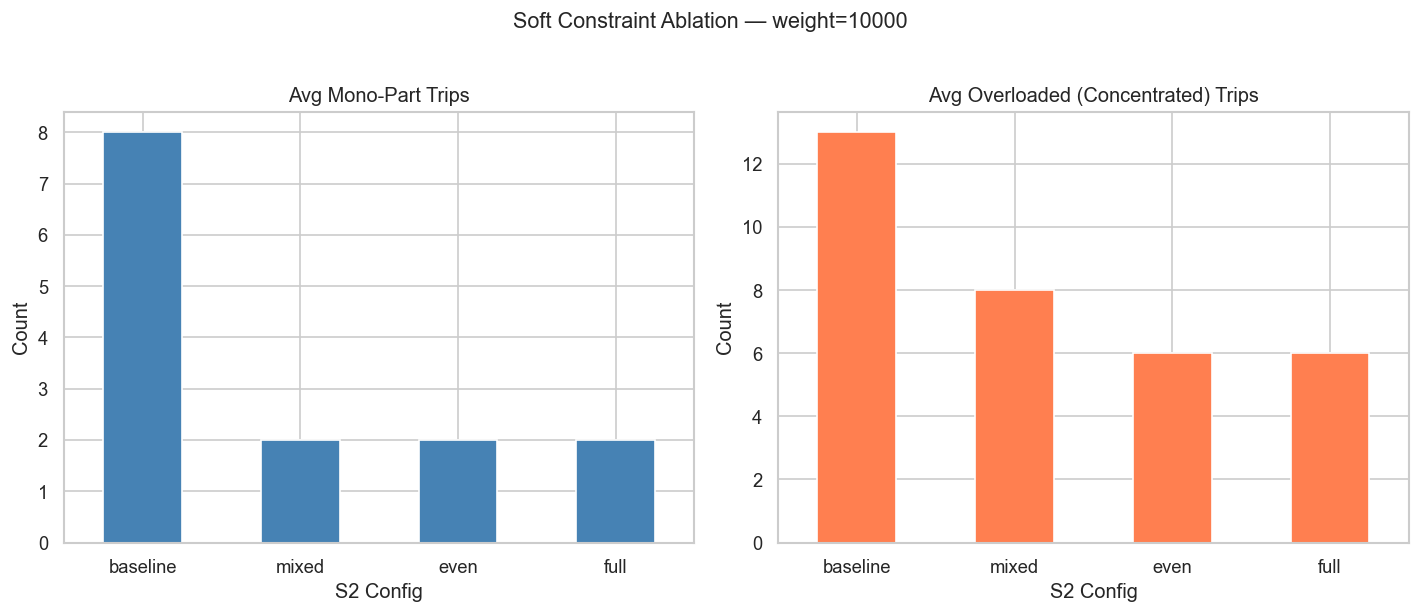

In [28]:
def plot_ablation_counts(df, weight=None):
    """Bar chart of mono_count and concentrated_count by config."""
    sub = df.copy()
    if weight is not None:
        sub = sub[sub["weight"] == weight]

    agg = sub.groupby("s2_config")[["mono_count", "concentrated_count"]].mean()
    agg = agg.reindex(config_order)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    agg["mono_count"].plot(kind="bar", ax=axes[0], color="steelblue")
    axes[0].set_title("Avg Mono-Part Trips")
    axes[0].set_ylabel("Count")
    axes[0].set_xlabel("S2 Config")
    axes[0].tick_params(axis="x", rotation=0)

    agg["concentrated_count"].plot(kind="bar", ax=axes[1], color="coral")
    axes[1].set_title("Avg Overloaded (Concentrated) Trips")
    axes[1].set_ylabel("Count")
    axes[1].set_xlabel("S2 Config")
    axes[1].tick_params(axis="x", rotation=0)

    w_str = f"weight={weight}" if weight is not None else "all weights"
    fig.suptitle(f"Soft Constraint Ablation — {w_str}", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


for w in sorted(df["weight"].unique()):
    plot_ablation_counts(df, weight=w)

## 5. R_α Single vs Global Heatmap

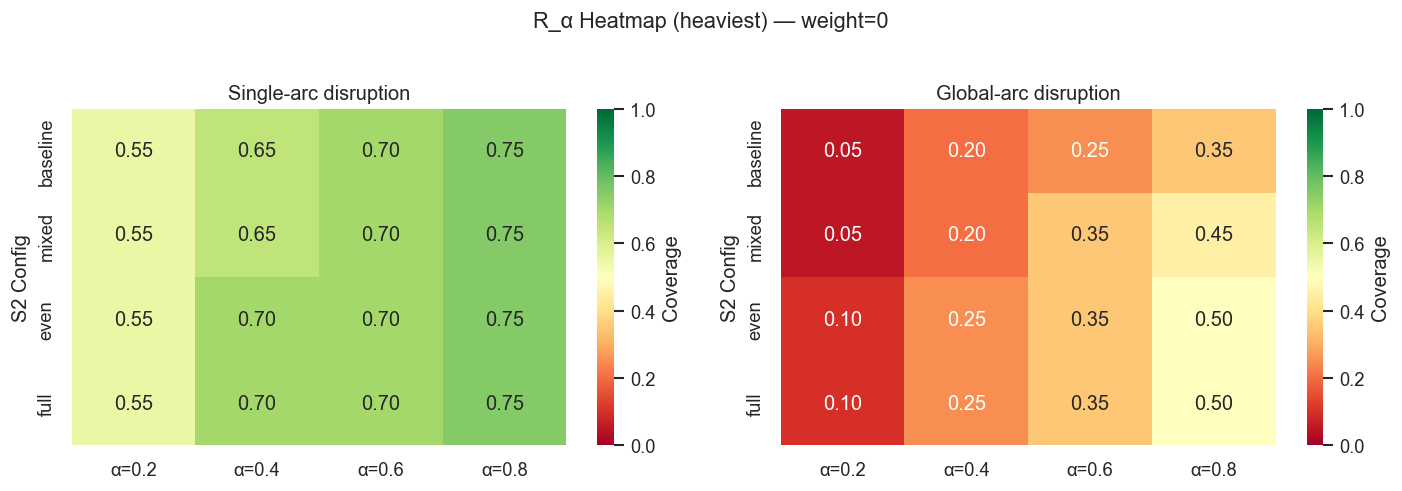

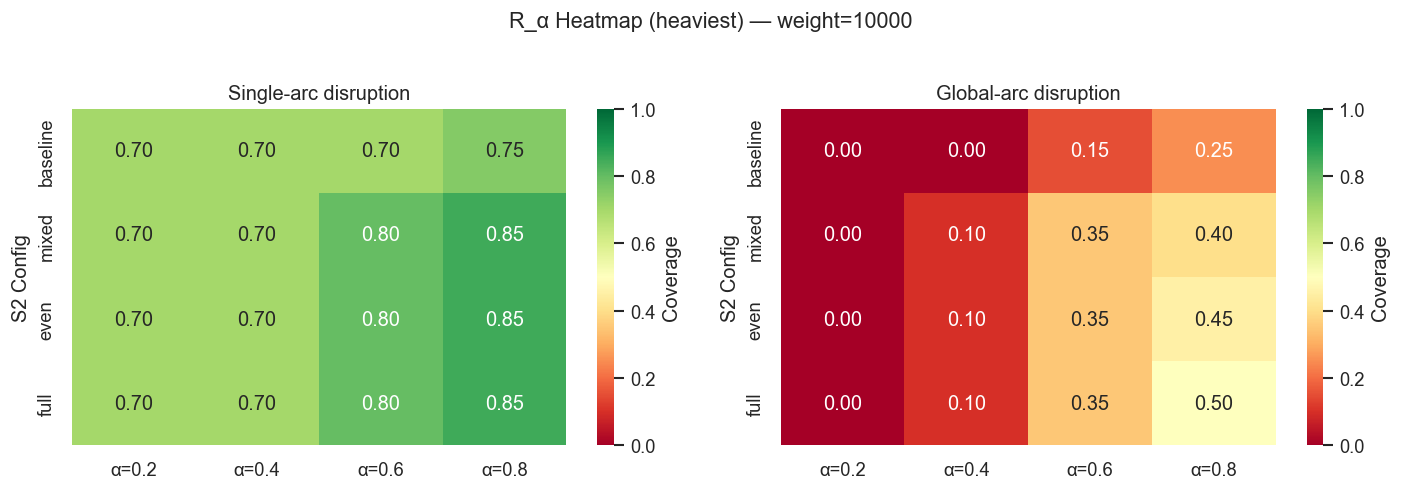

In [29]:
def plot_r_alpha_heatmap(df, strategy="heaviest", weight=None):
    """Heatmap: configs (rows) × alpha (cols), separate for single/global."""
    sub = df.copy()
    if weight is not None:
        sub = sub[sub["weight"] == weight]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for ax, mode in zip(axes, ["single", "global"]):
        data = []
        for config in config_order:
            cfg_df = sub[sub["s2_config"] == config]
            row_vals = []
            for a in alpha_vals:
                col = f"r_{strategy}_{mode}_{a}"
                if col in cfg_df.columns:
                    row_vals.append(cfg_df[col].mean())
                else:
                    row_vals.append(np.nan)
            data.append(row_vals)

        heatmap_df = pd.DataFrame(
            data, index=config_order,
            columns=[f"α={a}" for a in alpha_vals]
        )
        sns.heatmap(
            heatmap_df, annot=True, fmt=".2f", cmap="RdYlGn",
            vmin=0, vmax=1, ax=ax, cbar_kws={"label": "Coverage"}
        )
        ax.set_title(f"{mode.title()}-arc disruption")
        ax.set_ylabel("S2 Config")

    w_str = f"weight={weight}" if weight is not None else "all weights"
    fig.suptitle(f"R_α Heatmap ({strategy}) — {w_str}", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


for w in sorted(df["weight"].unique()):
    plot_r_alpha_heatmap(df, weight=w)

## 6. R_1 by Config × Instance Size

*(Requires multiple instance sizes in dataset)*

Only one size present (['paper']), skipping multi-size plot


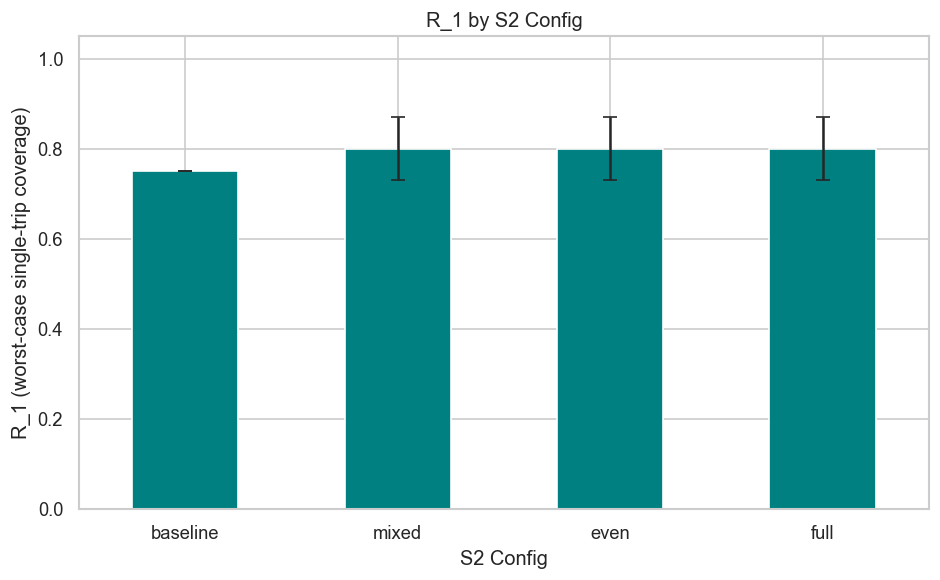

In [36]:
def plot_r1_by_size(df):
    """Grouped bar chart: R_1 by instance_size, colored by s2_config."""
    sub = df.dropna(subset=["r_1"])
    if sub.empty:
        print("No R_1 data available")
        return

    sizes_present = [s for s in size_order if s in sub["instance_size"].values]
    if len(sizes_present) < 2:
        print(f"Only one size present ({sizes_present}), skipping multi-size plot")
        # Still show single-size bar
        fig, ax = plt.subplots(figsize=(8, 5))
        agg = sub.groupby("s2_config")["r_1"].agg(["mean", "std"]).reindex(config_order)
        agg["mean"].plot(kind="bar", yerr=agg["std"], ax=ax, color="teal", capsize=4)
        ax.set_title("R_1 by S2 Config")
        ax.set_ylabel("R_1 (worst-case single-trip coverage)")
        ax.set_xlabel("S2 Config")
        ax.set_ylim(0, 1.05)
        ax.tick_params(axis="x", rotation=0)
        plt.tight_layout()
        plt.show()
        return

    fig, ax = plt.subplots(figsize=(12, 6))
    agg = sub.groupby(["instance_size", "s2_config"])["r_1"].mean().reset_index()
    pivot = agg.pivot(index="instance_size", columns="s2_config", values="r_1")
    pivot = pivot.reindex(sizes_present)
    pivot = pivot[config_order] if all(c in pivot.columns for c in config_order) else pivot

    pivot.plot(kind="bar", ax=ax, width=0.7)
    ax.set_title("R_1 by Instance Size and S2 Config")
    ax.set_ylabel("R_1 (worst-case coverage)")
    ax.set_xlabel("Instance Size")
    ax.set_ylim(0, 1.05)
    ax.legend(title="S2 Config")
    ax.tick_params(axis="x", rotation=0)
    plt.tight_layout()
    plt.show()


plot_r1_by_size(df)

## 8b. R_1 vs R_TR Scatter

Shows relationship between arc-level resilience (R_TR) and trip-level resilience (R_1).
Points above the diagonal = S2 packing improves upon S1 arc vulnerability.

## 7. Scalability (Solve Time by Instance Size)

*(Requires multiple instance sizes in dataset)*

In [42]:
def plot_scalability(df):
    """Stacked bar: S1 time + S2 time by instance size."""
    sizes_present = [s for s in size_order if s in df["instance_size"].values]
    if len(sizes_present) < 2:
        print(f"Only one size present ({sizes_present}), skipping scalability plot")
        return

    agg = df.groupby("instance_size")[["s1_time", "s2_time"]].mean()
    agg = agg.reindex(sizes_present)

    fig, ax = plt.subplots(figsize=(10, 5))
    agg.plot(kind="bar", stacked=True, ax=ax, color=["steelblue", "coral"])
    ax.set_title("Average Solve Time by Instance Size")
    ax.set_ylabel("Time (s)")
    ax.set_xlabel("Instance Size")
    ax.legend(["Stage 1", "Stage 2"])
    ax.tick_params(axis="x", rotation=0)
    plt.tight_layout()
    plt.show()


plot_scalability(df)

Only one size present (['paper']), skipping scalability plot


## 8. Cost-Resilience Pareto (Dispatch Cost vs R_1)

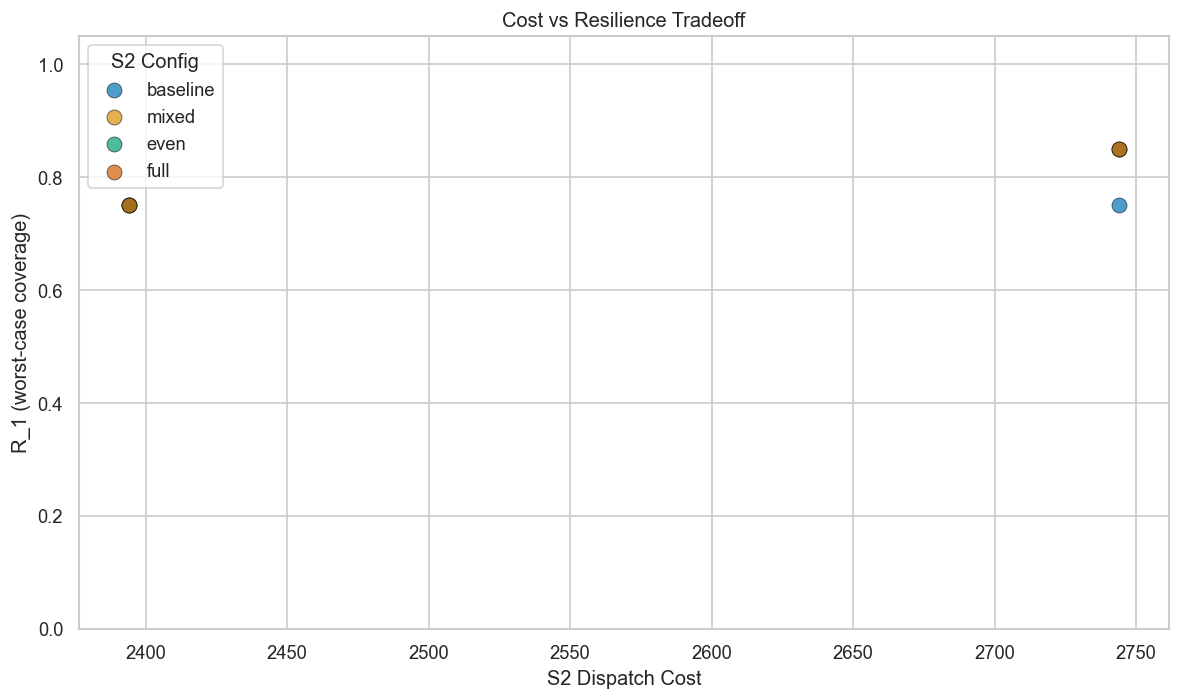

In [47]:
def plot_cost_resilience(df):
    """Scatter: dispatch cost (x) vs R_1 (y), colored by config."""
    sub = df.dropna(subset=["r_1", "s2_dispatch_cost"])
    if sub.empty:
        print("No cost-resilience data available")
        return

    fig, ax = plt.subplots(figsize=(10, 6))
    for config in config_order:
        cfg_df = sub[sub["s2_config"] == config]
        if cfg_df.empty:
            continue
        ax.scatter(
            cfg_df["s2_dispatch_cost"], cfg_df["r_1"],
            label=config, s=80, alpha=0.7, edgecolors="k", linewidths=0.5
        )

    ax.set_xlabel("S2 Dispatch Cost")
    ax.set_ylabel("R_1 (worst-case coverage)")
    ax.set_title("Cost vs Resilience Tradeoff")
    ax.legend(title="S2 Config")
    ax.set_ylim(0, 1.05)
    plt.tight_layout()
    plt.show()


plot_cost_resilience(df)

## 9. Relative Cost Increase: S2 Configs vs Baseline Across Weights

For each instance, compute the relative cost increase of each S2 config 
compared to baseline at the same weight:

$$\Delta\% = \frac{\text{cost}_{\text{config}} - \text{cost}_{\text{baseline}}}{\text{cost}_{\text{baseline}}} \times 100$$

Separate panels for small and large instances.

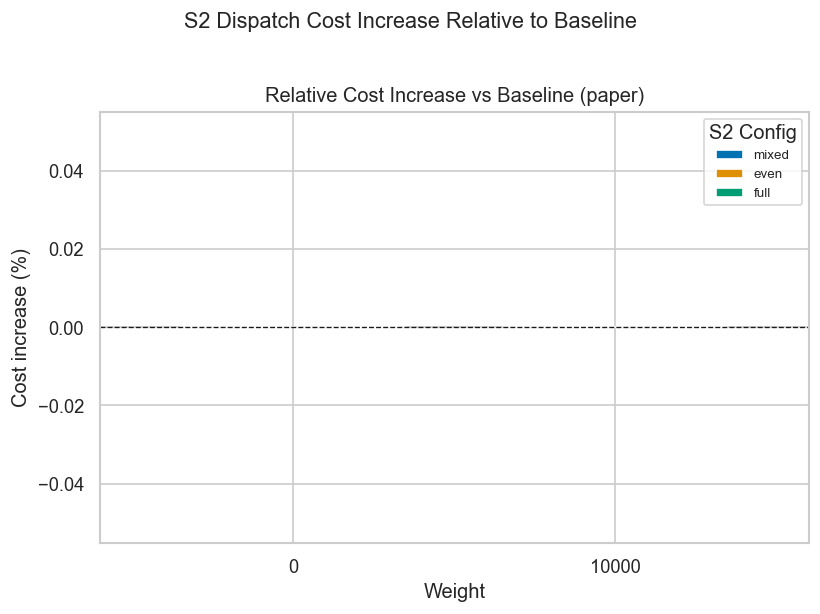

In [51]:
def plot_relative_cost_increase(df):
    """Relative S2 dispatch cost increase vs baseline, by weight and size."""
    sub = df.dropna(subset=["s2_dispatch_cost"]).copy()
    if sub.empty:
        print("No dispatch cost data")
        return

    # Compute baseline cost per (instance, weight)
    baseline = sub[sub["s2_config"] == "baseline"].set_index(
        ["instance_name", "weight"]
    )[["s2_dispatch_cost"]].rename(columns={"s2_dispatch_cost": "baseline_cost"})

    merged = sub.merge(
        baseline, left_on=["instance_name", "weight"], right_index=True, how="left"
    )
    merged["rel_cost_pct"] = (
        (merged["s2_dispatch_cost"] - merged["baseline_cost"])
        / merged["baseline_cost"] * 100
    )

    # Filter to non-baseline configs
    merged = merged[merged["s2_config"] != "baseline"]

    # Determine which sizes to show
    sizes_present = merged["instance_size"].unique().tolist()
    target_sizes = []
    for s in ["small", "paper"]:
        if s in sizes_present:
            target_sizes.append(s)
            break
    for s in ["large", "xlarge", "medium", "industrylite"]:
        if s in sizes_present:
            target_sizes.append(s)
            break

    # If only one size, just plot it
    if not target_sizes:
        target_sizes = sizes_present[:1]

    n_panels = max(len(target_sizes), 1)
    fig, axes = plt.subplots(1, n_panels, figsize=(7 * n_panels, 5), squeeze=False)
    axes = axes.flatten()

    for i, size in enumerate(target_sizes):
        ax = axes[i]
        size_df = merged[merged["instance_size"] == size]

        if size_df.empty:
            ax.set_title(f"{size} — no data")
            continue

        agg = size_df.groupby(["weight", "s2_config"])["rel_cost_pct"].mean().reset_index()
        pivot = agg.pivot(index="weight", columns="s2_config", values="rel_cost_pct")

        pivot.plot(kind="bar", ax=ax, width=0.7)
        ax.set_title(f"Relative Cost Increase vs Baseline ({size})")
        ax.set_ylabel("Cost increase (%)")
        ax.set_xlabel("Weight")
        ax.axhline(0, color="k", linewidth=0.8, linestyle="--")
        ax.legend(title="S2 Config", fontsize=8)
        ax.tick_params(axis="x", rotation=0)

    # Hide unused axes
    for j in range(len(target_sizes), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle("S2 Dispatch Cost Increase Relative to Baseline", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


plot_relative_cost_increase(df)

## 9b. Relative Cost Increase with R_1 Improvement

Shows cost increase vs resilience gain — are we paying more for better resilience?

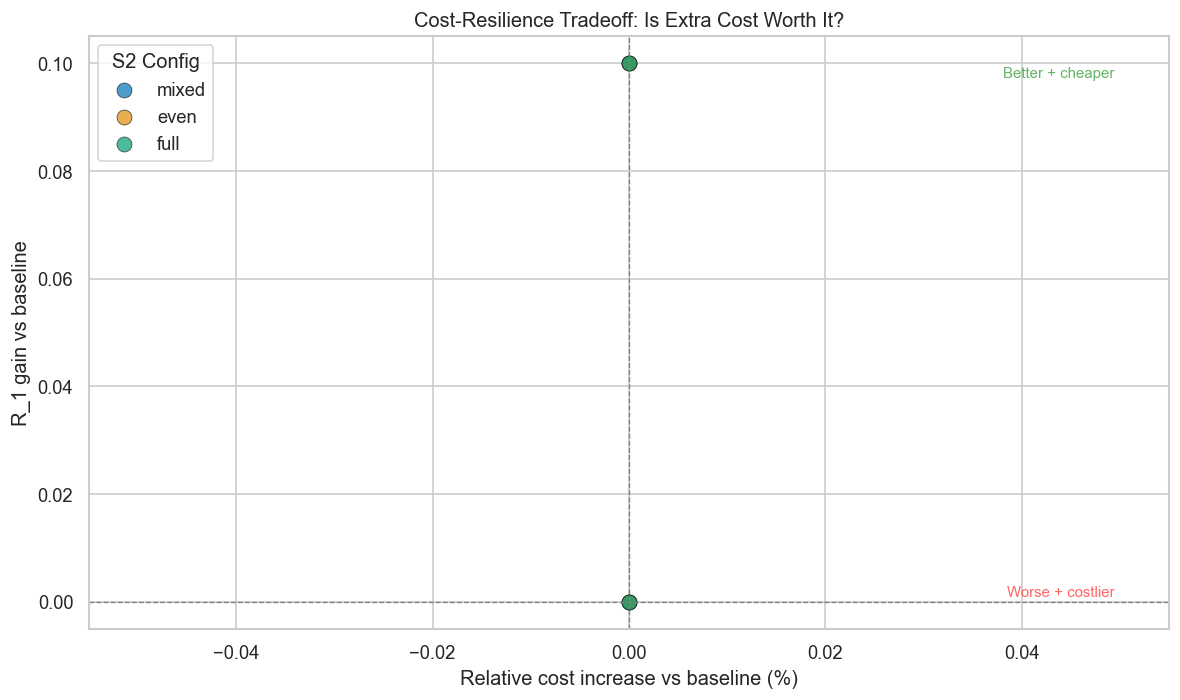

In [52]:
def plot_cost_vs_resilience_gain(df):
    """Scatter: relative cost increase vs R_1 improvement over baseline."""
    sub = df.dropna(subset=["s2_dispatch_cost", "r_1"]).copy()
    if sub.empty:
        print("No data for cost vs resilience gain")
        return

    baseline = sub[sub["s2_config"] == "baseline"].set_index(
        ["instance_name", "weight"]
    )[["s2_dispatch_cost", "r_1"]].rename(
        columns={"s2_dispatch_cost": "baseline_cost", "r_1": "baseline_r1"}
    )

    merged = sub.merge(
        baseline, left_on=["instance_name", "weight"], right_index=True, how="left"
    )
    merged["rel_cost_pct"] = (
        (merged["s2_dispatch_cost"] - merged["baseline_cost"])
        / merged["baseline_cost"] * 100
    )
    merged["r1_gain"] = merged["r_1"] - merged["baseline_r1"]

    merged = merged[merged["s2_config"] != "baseline"]

    if merged.empty:
        print("No non-baseline data")
        return

    fig, ax = plt.subplots(figsize=(10, 6))
    for config in ["mixed", "even", "full"]:
        cfg_df = merged[merged["s2_config"] == config]
        if cfg_df.empty:
            continue
        ax.scatter(
            cfg_df["rel_cost_pct"], cfg_df["r1_gain"],
            label=config, s=80, alpha=0.7, edgecolors="k", linewidths=0.5
        )

    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")
    ax.set_xlabel("Relative cost increase vs baseline (%)")
    ax.set_ylabel("R_1 gain vs baseline")
    ax.set_title("Cost-Resilience Tradeoff: Is Extra Cost Worth It?")
    ax.legend(title="S2 Config")
    # Annotate quadrants
    ax.text(0.95, 0.95, "Better + cheaper", transform=ax.transAxes,
            ha="right", va="top", fontsize=9, color="green", alpha=0.6)
    ax.text(0.95, 0.05, "Worse + costlier", transform=ax.transAxes,
            ha="right", va="bottom", fontsize=9, color="red", alpha=0.6)
    plt.tight_layout()
    plt.show()


plot_cost_vs_resilience_gain(df)

## Summary Table

In [53]:
# Quick summary table
summary_cols = [
    "s2_config", "weight", "instance_size",
    "r_tr", "r_1", "k_1",
    "mono_count", "concentrated_count",
    "s1_dispatch_cost", "s2_dispatch_cost", "cost_saving",
    "s1_time", "s2_time",
]
summary_cols = [c for c in summary_cols if c in df.columns]

summary = df.groupby(["instance_size", "weight", "s2_config"]).agg(
    r_tr=("r_tr", "mean"),
    r_1=("r_1", "mean"),
    k_1=("k_1", "mean"),
    mono=("mono_count", "mean"),
    conc=("concentrated_count", "mean"),
    s2_cost=("s2_dispatch_cost", "mean"),
    cost_saving=("cost_saving", "mean"),
    s1_t=("s1_time", "mean"),
    s2_t=("s2_time", "mean"),
    n=("r_tr", "count"),
).round(3).reset_index()

summary

,instance_size,weight,s2_config,r_tr,r_1,k_1,mono,conc,s2_cost,cost_saving,s1_t,s2_t,n
0,paper,0,baseline,0.5,0.75,0.75,2.0,9.0,2394.0,0.0,0.950,0.008,1
1,paper,0,mixed,0.5,0.75,0.75,1.0,9.0,2394.0,0.0,0.950,0.009,1
2,paper,0,even,0.5,0.75,0.75,1.0,5.0,2394.0,0.0,0.950,0.011,1
3,paper,0,full,0.5,0.75,0.75,1.0,5.0,2394.0,0.0,0.950,0.011,1
4,paper,10000,baseline,0.7,0.75,0.75,8.0,13.0,2744.0,0.0,0.749,0.006,1
5,paper,10000,mixed,0.7,0.85,0.85,2.0,8.0,2744.0,0.0,0.749,0.012,1
6,paper,10000,even,0.7,0.85,0.85,2.0,6.0,2744.0,0.0,0.749,0.010,1
7,paper,10000,full,0.7,0.85,0.85,2.0,6.0,2744.0,0.0,0.749,0.015,1


## 10. Cross-Comparison: One-Shot vs Two-Stage

Compares the benchmark one-shot encoding (naive/clingcon) against the two-stage decomposition:
- Solve time: one-shot total vs S1+S2 combined
- Solution quality: one-shot cost vs S1 nominal cost  
- Grounding size: atoms comparison

Requires the benchmark CSV from `experiments/benchmark/results/`.